Group members (Name, ID): 

•	Vishal Sharma (0876108)

•	Krupa Patel (0876474)

•	Om Patel (0876316)


In [2]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv")

In [5]:
df.head()

,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18330 entries, 0 to 18329
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Facility Name               18330 non-null  object 
 1   Facility ID                 18330 non-null  int64  
 2   State                       18330 non-null  object 
 3   Measure Name                18330 non-null  object 
 4   Number of Discharges        8242 non-null   float64
 5   Footnote                    6987 non-null   float64
 6   Excess Readmission Ratio    11720 non-null  float64
 7   Predicted Readmission Rate  11720 non-null  float64
 8   Expected Readmission Rate   11720 non-null  float64
 9   Number of Readmissions      11720 non-null  object 
 10  Start Date                  18330 non-null  object 
 11  End Date                    18330 non-null  object 
dtypes: float64(5), int64(1), object(6)
memory usage: 1.7+ MB


In [7]:
df.describe()

,Facility ID,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate
count,18330.000000,8242.000000,6987.000000,11720.000000,11720.000000,11720.000000
mean,262031.979378,283.416282,4.550308,1.001777,14.981461,14.947978
std,164868.122655,270.929023,6.181702,0.082050,4.763655,4.620865
min,10001.000000,0.000000,1.000000,0.469800,1.908000,3.087600
25%,110069.000000,117.000000,1.000000,0.958200,12.529550,12.623750
50%,250048.000000,198.000000,5.000000,0.997300,15.860150,15.856550
75%,390138.000000,358.000000,5.000000,1.042300,18.418500,18.500925
max,670342.000000,3672.000000,29.000000,1.629700,28.164300,26.865400


In [8]:
df.columns

Index(['Facility Name', 'Facility ID', 'State', 'Measure Name',
       'Number of Discharges', 'Footnote', 'Excess Readmission Ratio',
       'Predicted Readmission Rate', 'Expected Readmission Rate',
       'Number of Readmissions', 'Start Date', 'End Date'],
      dtype='object')

In [9]:
df = df[['Facility Name',
         'State',
         'Measure Name',
         'Number of Discharges',
         'Excess Readmission Ratio']]

In [10]:
df.head()

,Facility Name,State,Measure Name,Number of Discharges,Excess Readmission Ratio
0,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-HIP-KNEE-HRRP,NaN,0.9875
1,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-CABG-HRRP,137.0,0.9531
2,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-AMI-HRRP,273.0,0.9370
3,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-COPD-HRRP,122.0,0.9823
4,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-PN-HRRP,507.0,0.9871


In [11]:
#Missing Values
df.isnull().sum()

Facility Name                   0
State                           0
Measure Name                    0
Number of Discharges        10088
Excess Readmission Ratio     6610
dtype: int64

In [12]:
(df == "Not Available").sum()

Facility Name               0
State                       0
Measure Name                0
Number of Discharges        0
Excess Readmission Ratio    0
dtype: int64

In [13]:
#Handle Missing Values  
#Replace Not Available values with NaN.
df.replace("Not Available", pd.NA, inplace=True)

In [14]:
df['Excess Readmission Ratio'] = pd.to_numeric(df['Excess Readmission Ratio'], errors='coerce')
df['Number of Discharges'] = pd.to_numeric(df['Number of Discharges'], errors='coerce')

In [15]:
#Remove rows with missing values
df = df.dropna()

In [16]:
df.isnull().sum()

Facility Name               0
State                       0
Measure Name                0
Number of Discharges        0
Excess Readmission Ratio    0
dtype: int64

In [17]:
#Check dataset size
df.shape

(8037, 5)

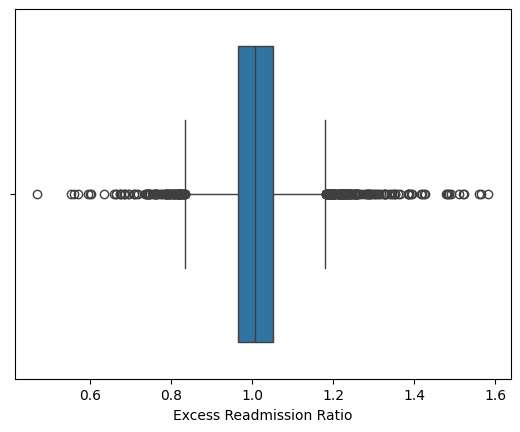

In [18]:
#Detect Outliers
sns.boxplot(x=df['Excess Readmission Ratio'])
plt.show()

In [19]:
#Remove Outliers
Q1 = df['Excess Readmission Ratio'].quantile(0.25)
Q3 = df['Excess Readmission Ratio'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Excess Readmission Ratio'] >= lower) & (df['Excess Readmission Ratio'] <= upper)]

In [20]:
#Basic Dataset Overview
#Check number of states
df['State'].nunique()

51

In [21]:
#Check unique measures
df['Measure Name'].unique()

array(['READM-30-CABG-HRRP', 'READM-30-AMI-HRRP', 'READM-30-COPD-HRRP',
       'READM-30-PN-HRRP', 'READM-30-HF-HRRP', 'READM-30-HIP-KNEE-HRRP'],
      dtype=object)

In [22]:
#Check number of hospitals
df['Facility Name'].nunique()

2404

In [23]:
#Average Readmission Ratio by State
state_readmission = df.groupby('State')['Excess Readmission Ratio'].mean().sort_values(ascending=False)

print(state_readmission.head(10))

State
MA    1.033118
NJ    1.028220
NV    1.025818
MS    1.024476
FL    1.021128
IL    1.019385
LA    1.018142
CA    1.017621
WV    1.017441
AL    1.016722
Name: Excess Readmission Ratio, dtype: float64


In [24]:
#Readmission Ratio by Measure
measure_readmission = df.groupby('Measure Name')['Excess Readmission Ratio'].mean().sort_values(ascending=False)

print(measure_readmission)

Measure Name
READM-30-CABG-HRRP        1.017077
READM-30-COPD-HRRP        1.010370
READM-30-AMI-HRRP         1.010054
READM-30-HIP-KNEE-HRRP    1.007313
READM-30-PN-HRRP          1.005617
READM-30-HF-HRRP          1.003287
Name: Excess Readmission Ratio, dtype: float64


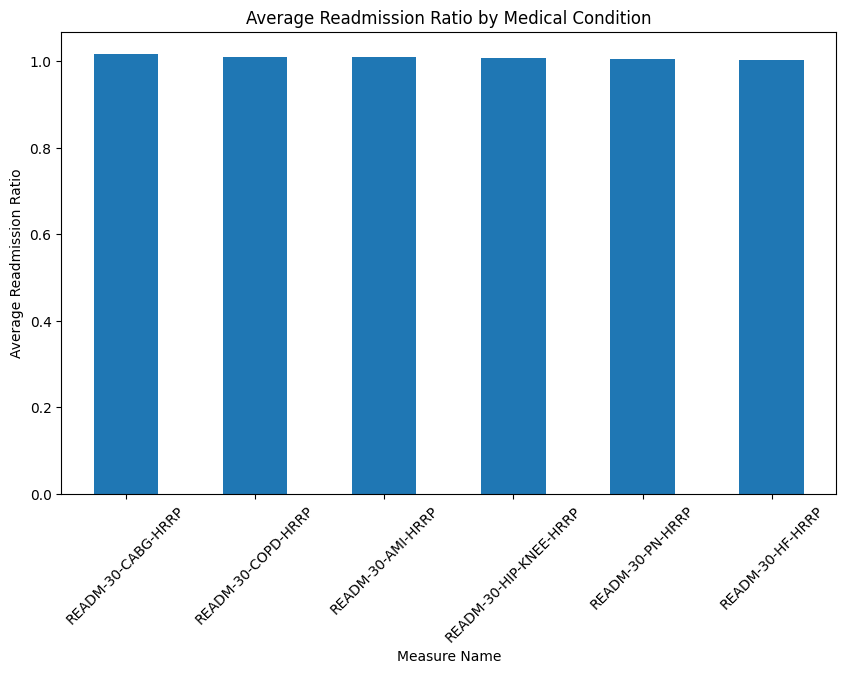

In [25]:
#Readmission by Medical Condition
plt.figure(figsize=(10,6))
measure_readmission.plot(kind='bar')
plt.title("Average Readmission Ratio by Medical Condition")
plt.xlabel("Measure Name")
plt.ylabel("Average Readmission Ratio")
plt.xticks(rotation=45)
plt.show()

In [26]:
#Top Hospitals with Highest Readmission Ratio
top_hospitals = df.sort_values(by='Excess Readmission Ratio', ascending=False)

top_hospitals[['Facility Name','State','Excess Readmission Ratio']].head(10)

,Facility Name,State,Excess Readmission Ratio
1703,WASHINGTON HOSPITAL,CA,1.1804
1535,VALLEY PRESBYTERIAN HOSPITAL,CA,1.1803
4511,SAVANNAH HEALTH SERVICES LLC DBA MEMORIAL HEAL...,GA,1.1803
6973,MERCY HEALTH - LOURDES HOSPITAL,KY,1.1803
3779,HCA FLORIDA AVENTURA HOSPITAL,FL,1.1801
12866,COMANCHE COUNTY MEMORIAL HOSPITAL,OK,1.1801
5896,ST MARY MEDICAL CENTER INC,IN,1.1800
7879,UNIVERSITY OF MD ST JOSEPH MEDICAL CENTER,MD,1.1797
12160,PARMA COMMUNITY GENERAL HOSPITAL,OH,1.1793
8087,BAYSTATE MEDICAL CENTER,MA,1.1792


In [27]:
#Save Cleaned Dataset

df.to_csv("cleaned_readmission_data.csv", index=False)

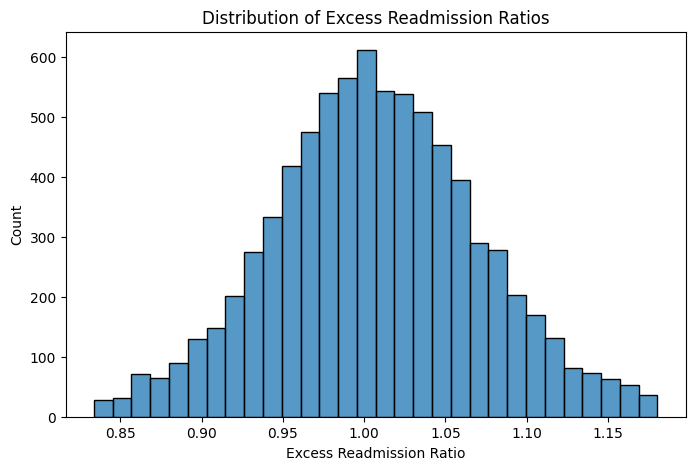

In [28]:
#Distribution of Readmission Ratios
plt.figure(figsize=(8,5))
sns.histplot(df['Excess Readmission Ratio'], bins=30)
plt.title("Distribution of Excess Readmission Ratios")
plt.show()

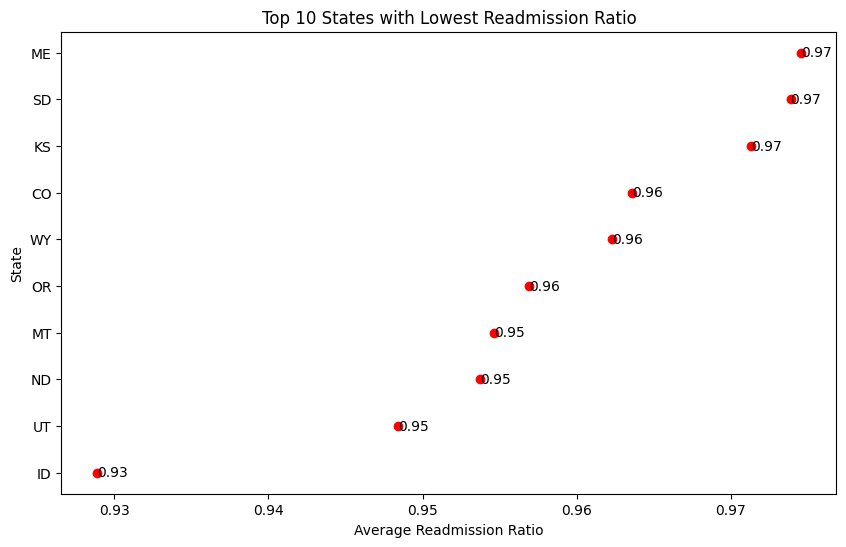

In [29]:
# Top 10 States with Lowest Readmission Ratio

lowest_states = state_readmission.sort_values(ascending=True).head(10)

plt.figure(figsize=(10,6))
plt.scatter(lowest_states.values, lowest_states.index, color='red')

for i, value in enumerate(lowest_states.values):
    plt.text(value, i, f"{value:.2f}", va='center')

plt.title("Top 10 States with Lowest Readmission Ratio")
plt.xlabel("Average Readmission Ratio")
plt.ylabel("State")

plt.show()

In [30]:
bottom_states = df.groupby('State')['Excess Readmission Ratio'] \
                  .mean() \
                  .sort_values(ascending=True) \
                  .head(10)

print(bottom_states)

State
ID    0.928848
UT    0.948421
ND    0.953752
MT    0.954643
OR    0.956941
WY    0.962277
CO    0.963607
KS    0.971315
SD    0.973885
ME    0.974576
Name: Excess Readmission Ratio, dtype: float64


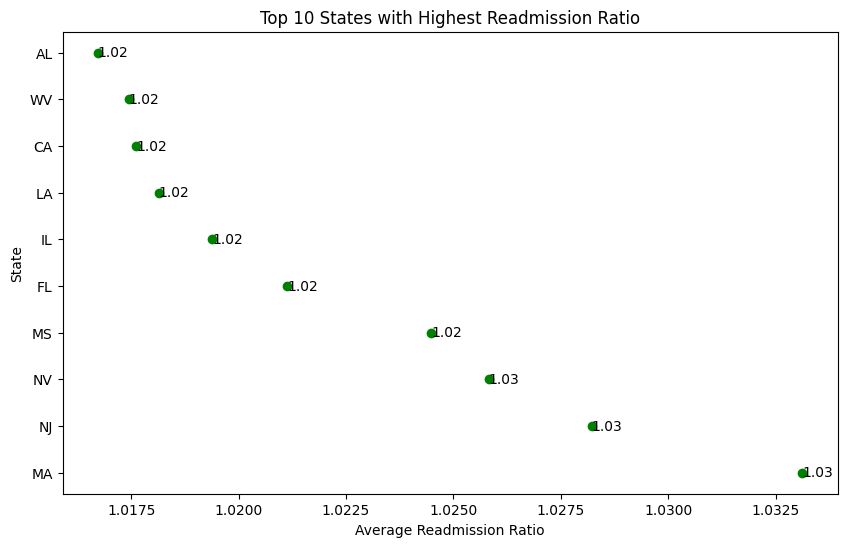

In [31]:
#Top 10 States with highest Readmission Ratio

highest_states = state_readmission.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.scatter(highest_states.values, highest_states.index, color='green')

for i, value in enumerate(highest_states.values):
    plt.text(value, i, f"{value:.2f}", va='center')

plt.title("Top 10 States with Highest Readmission Ratio")
plt.xlabel("Average Readmission Ratio")
plt.ylabel("State")

plt.show()

In [32]:
top_states = df.groupby('State')['Excess Readmission Ratio'] \
               .mean() \
               .sort_values(ascending=False) \
               .head(10)

print(top_states)

State
MA    1.033118
NJ    1.028220
NV    1.025818
MS    1.024476
FL    1.021128
IL    1.019385
LA    1.018142
CA    1.017621
WV    1.017441
AL    1.016722
Name: Excess Readmission Ratio, dtype: float64


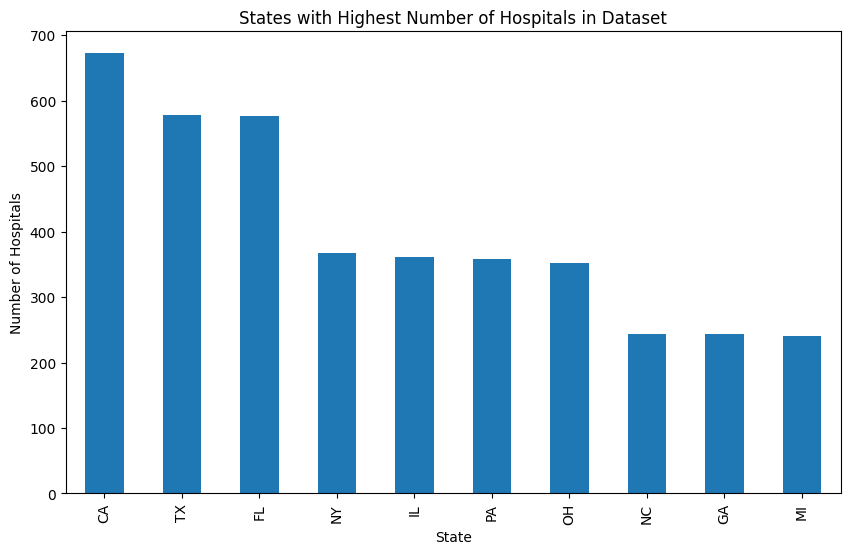

In [33]:
#Number of Hospitals per State

state_counts = df['State'].value_counts()

plt.figure(figsize=(10,6))
state_counts.head(10).plot(kind='bar')
plt.title("States with Highest Number of Hospitals in Dataset")
plt.xlabel("State")
plt.ylabel("Number of Hospitals")
plt.show()

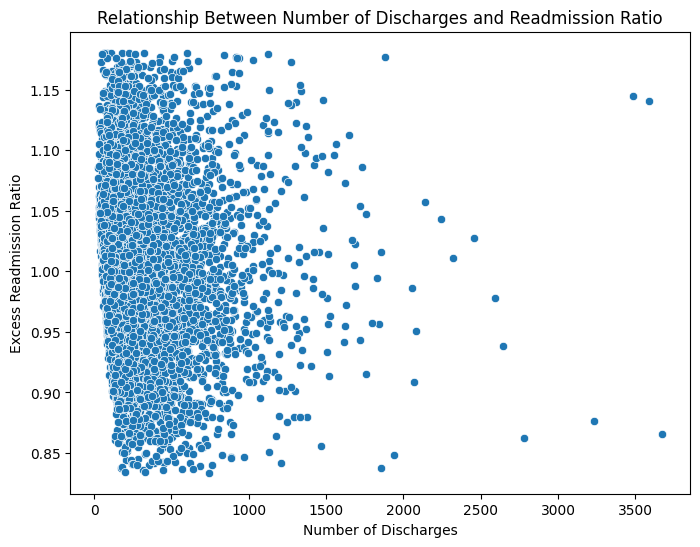

In [34]:
#Scatter Plot: Discharges vs Readmission Ratio
#This explores if patient volume affects readmission rates.

plt.figure(figsize=(8,6))
sns.scatterplot(x='Number of Discharges', y='Excess Readmission Ratio', data=df)
plt.title("Relationship Between Number of Discharges and Readmission Ratio")
plt.xlabel("Number of Discharges")
plt.ylabel("Excess Readmission Ratio")
plt.show()

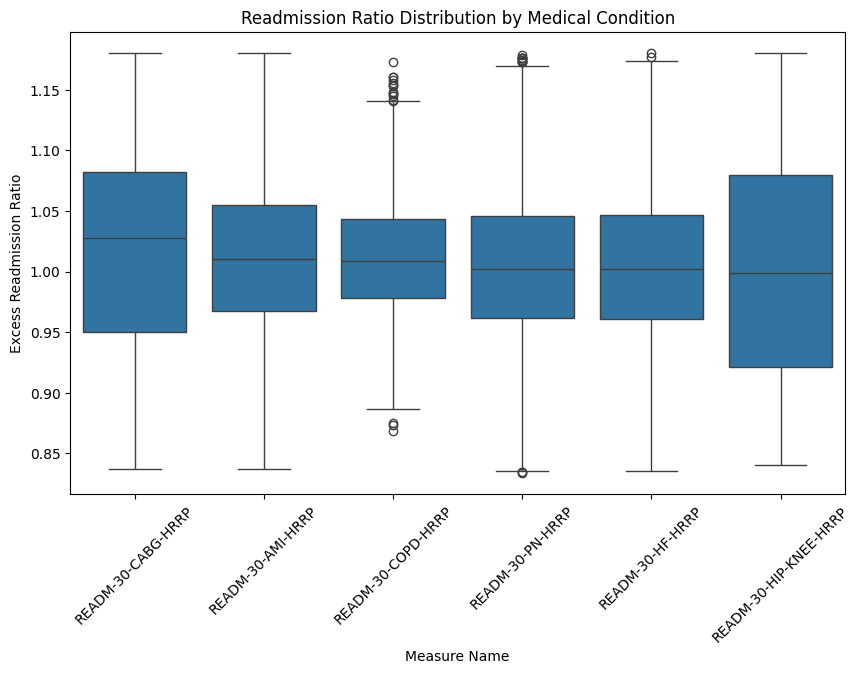

In [35]:
#Boxplot by Medical Condition
#This compares the distribution of readmission ratios across conditions

plt.figure(figsize=(10,6))
sns.boxplot(x='Measure Name', y='Excess Readmission Ratio', data=df)
plt.xticks(rotation=45)
plt.title("Readmission Ratio Distribution by Medical Condition")
plt.show()

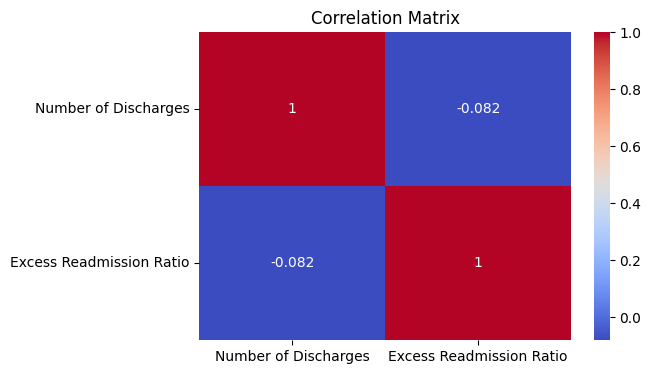

In [36]:
numeric_cols = df[['Number of Discharges','Excess Readmission Ratio']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

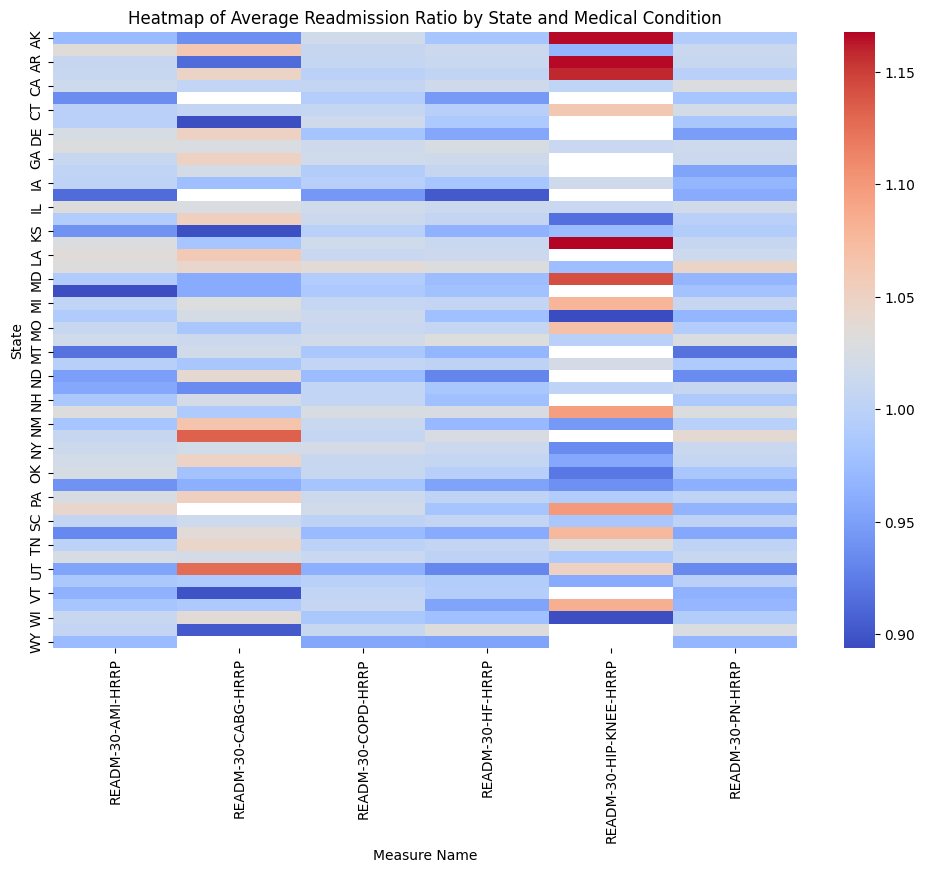

In [37]:
#Heatmap of Average Readmission Ratio by State and Measure

pivot_table = df.pivot_table(
    values='Excess Readmission Ratio',
    index='State',
    columns='Measure Name',
    aggfunc='mean'
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, cmap='coolwarm')
plt.title("Heatmap of Average Readmission Ratio by State and Medical Condition")
plt.show()

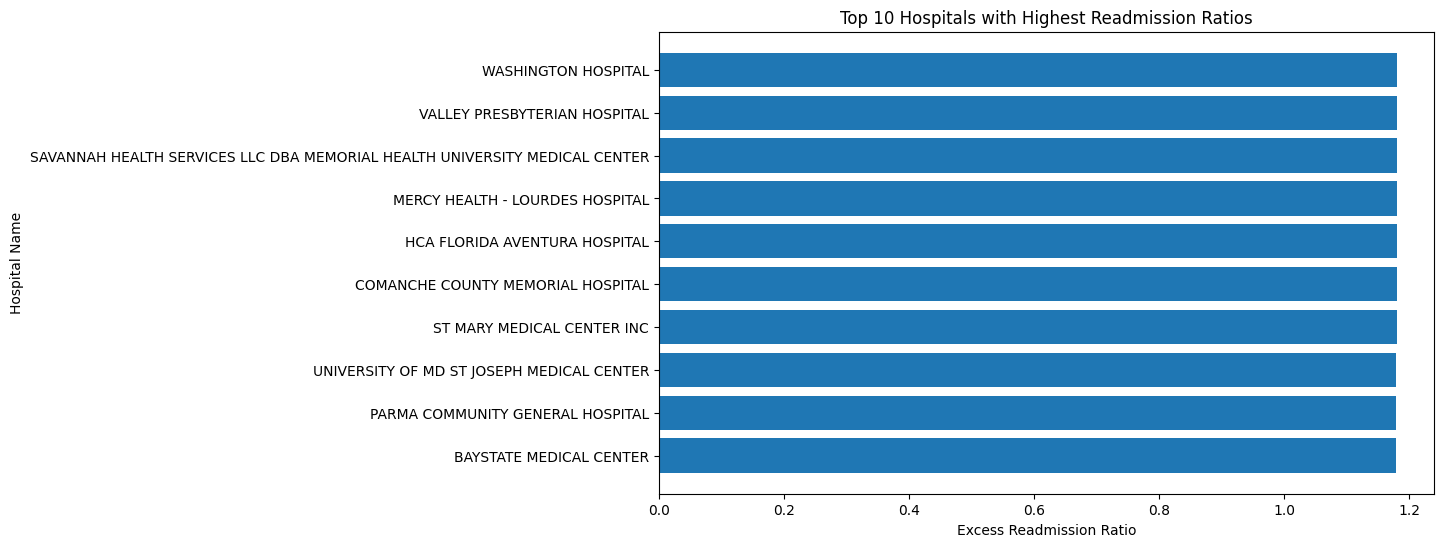

In [38]:
#Top 10 Hospitals with Highest Readmission Ratios (Worst)
#Hospitals with higher Excess Readmission Ratio generally indicate more readmissions than expected.

worst_hospitals = df.sort_values(by='Excess Readmission Ratio', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(worst_hospitals['Facility Name'], worst_hospitals['Excess Readmission Ratio'])
plt.title("Top 10 Hospitals with Highest Readmission Ratios")
plt.xlabel("Excess Readmission Ratio")
plt.ylabel("Hospital Name")
plt.gca().invert_yaxis()
plt.show()

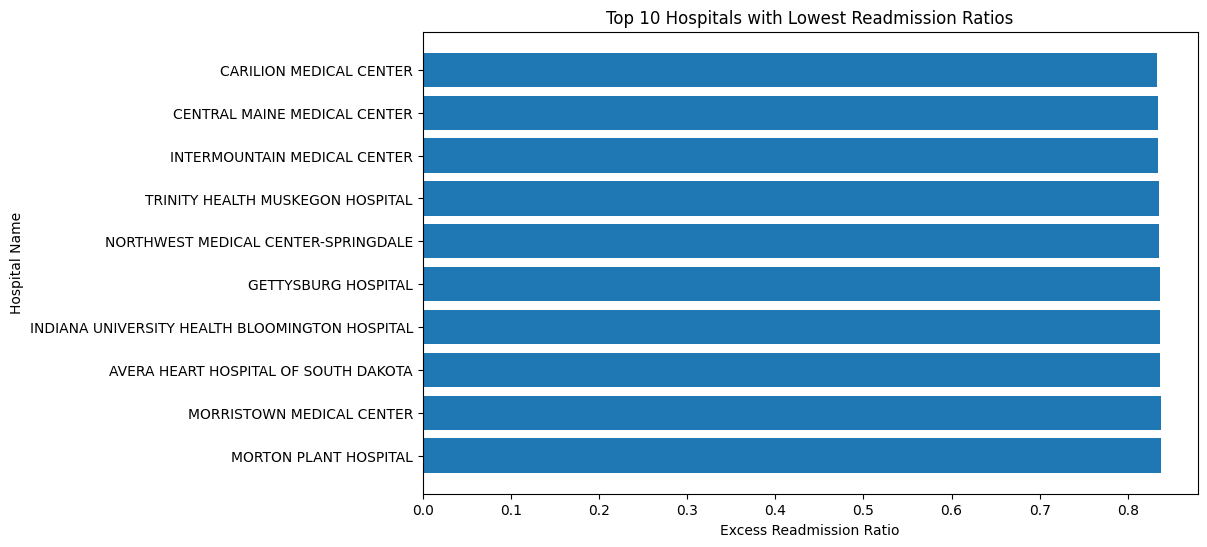

In [39]:
#Top 10 Hospitals with Lowest Readmission Ratios (Best)
#Hospitals with lower readmission ratios indicate better patient outcomes.

best_hospitals = df.sort_values(by='Excess Readmission Ratio').head(10)

plt.figure(figsize=(10,6))
plt.barh(best_hospitals['Facility Name'], best_hospitals['Excess Readmission Ratio'])
plt.title("Top 10 Hospitals with Lowest Readmission Ratios")
plt.xlabel("Excess Readmission Ratio")
plt.ylabel("Hospital Name")
plt.gca().invert_yaxis()
plt.show()

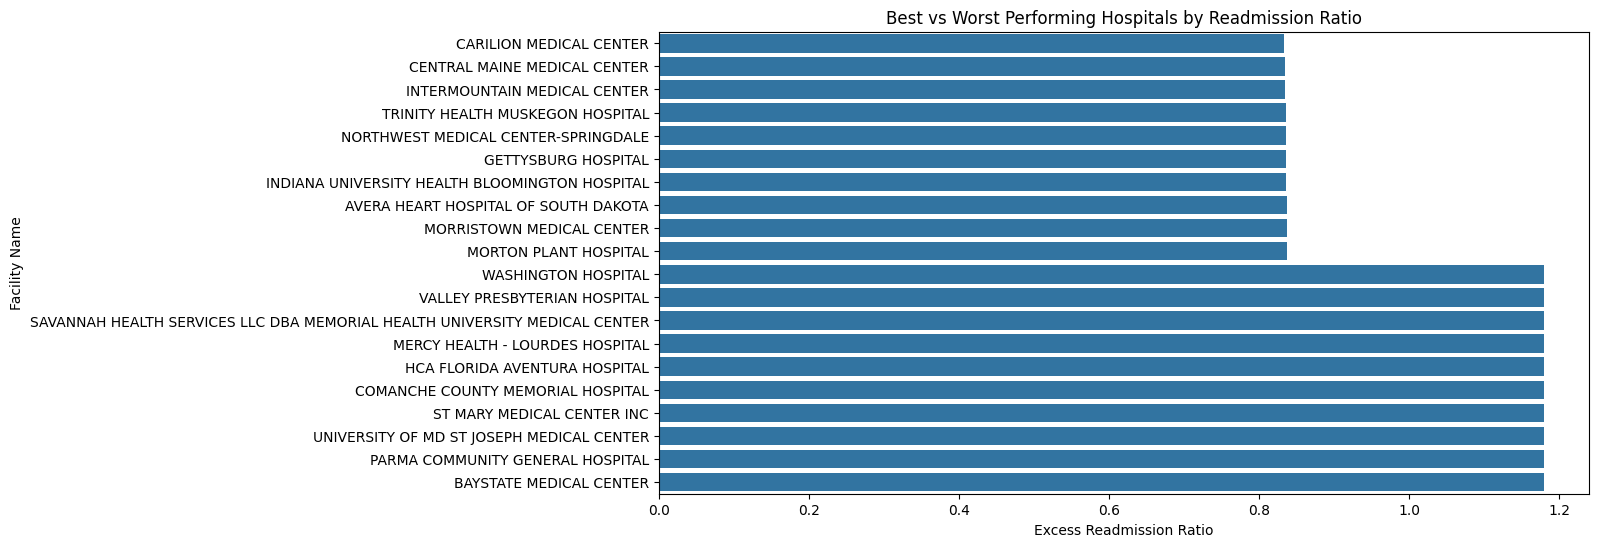

In [40]:
#Combined Comparison Chart (Best vs Worst)
comparison = pd.concat([best_hospitals, worst_hospitals])

plt.figure(figsize=(12,6))
sns.barplot(
    x='Excess Readmission Ratio',
    y='Facility Name',
    data=comparison
)

plt.title("Best vs Worst Performing Hospitals by Readmission Ratio")
plt.show()

ML 

In [41]:
#ML Libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
#Prepare Data for ML

df_ml = df.copy()

# Select important columns
df_ml = df_ml[['State', 'Measure Name', 'Number of Discharges', 'Excess Readmission Ratio']]



In [43]:
# Convert Categorical to Numeric

df_ml = pd.get_dummies(df_ml, columns=['State', 'Measure Name'], drop_first=True)

In [44]:
# Define X and y

X = df_ml.drop('Excess Readmission Ratio', axis=1)
y = df_ml['Excess Readmission Ratio']

In [45]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
# Train Model

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [47]:
# Make Predictions

y_pred = model.predict(X_test)

In [48]:
# Evaluate Model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.003960268033761524
R2 Score: 0.031108412258538554


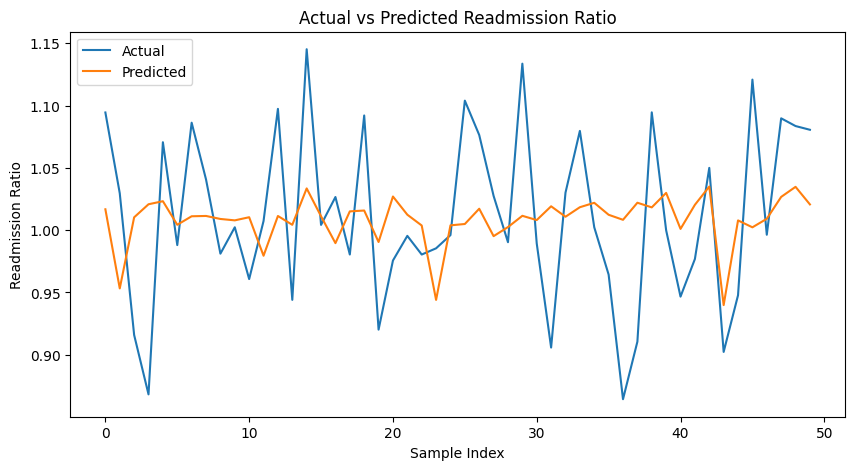

In [49]:
# Visualization (Actual vs Predicted)

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred[:50], label='Predicted')

plt.title("Actual vs Predicted Readmission Ratio")
plt.xlabel("Sample Index")
plt.ylabel("Readmission Ratio")
plt.legend()

plt.show()

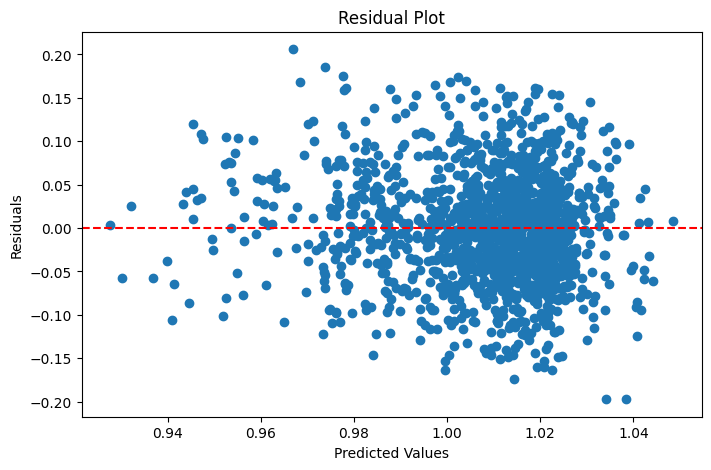

In [50]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='r', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

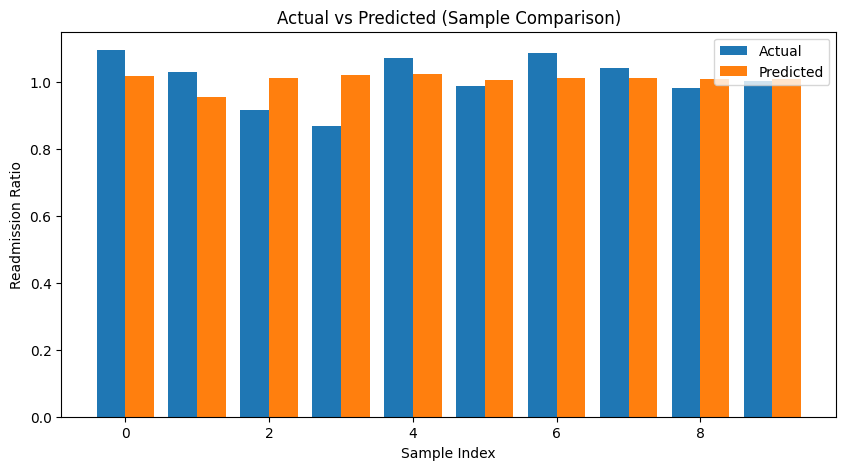

In [51]:
import numpy as np

n = 10  # number of samples

x = np.arange(n)

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, y_test.values[:n], width=0.4, label='Actual')
plt.bar(x + 0.2, y_pred[:n], width=0.4, label='Predicted')

plt.title("Actual vs Predicted (Sample Comparison)")
plt.xlabel("Sample Index")
plt.ylabel("Readmission Ratio")
plt.legend()

plt.show()

In [52]:
# Decision Tree

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=5)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree R2: 0.04721417146272233


In [53]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: -0.07583582929765642


In [54]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting R2:", r2_score(y_test, y_pred_gb))

Gradient Boosting R2: 0.07769264271280829


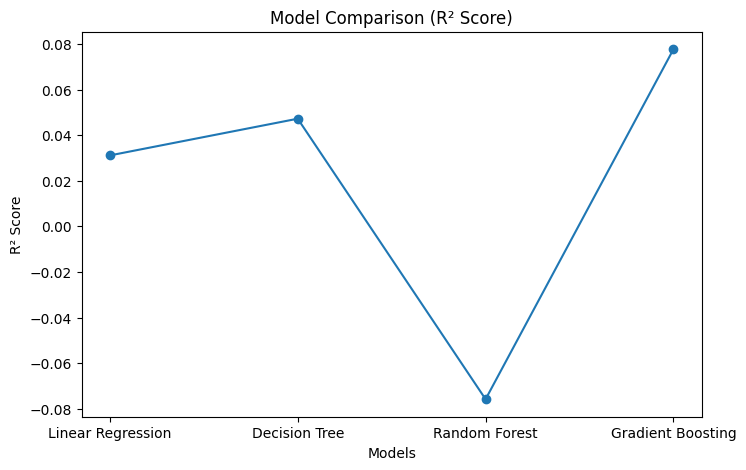

In [55]:
# Model Comparison

import pandas as pd
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
r2_scores = [
    r2_score(y_test, y_pred),       # Linear
    r2_score(y_test, y_pred_dt),    # Decision Tree
    r2_score(y_test, y_pred_rf),    # Random Forest
    r2_score(y_test, y_pred_gb)     # Gradient Boosting
]

plt.figure(figsize=(8,5))
plt.plot(models, r2_scores, marker='o')

plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.show()

# Hypothesis 1: Relationship Between Discharges and Readmission
Correlation Analysis (Discharges vs Readmission Ratio)

H0 (Null Hypothesis):

There is no relationship between the number of discharges and the excess readmission ratio.

H1 (Alternative Hypothesis):

There is a significant relationship between the number of discharges and the excess readmission ratio.



In [56]:
from scipy import stats

corr, p_value = stats.pearsonr(df['Number of Discharges'], df['Excess Readmission Ratio'])

print("Correlation Value:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis → Significant Relationship Exists")
else:
    print("Fail to Reject Null Hypothesis → No Significant Relationship")

Correlation Value: -0.08151205729144229
P-value: 5.777462469594009e-13
Reject Null Hypothesis → Significant Relationship Exists


Conclusion:

A statistically significant but weak relationship exists between discharges and readmission ratio.

# Hypothesis 2: Small vs Large Hospitals Comparison
Independent Sample T-Test (Hospital Size Comparison)


H0 (Null Hypothesis):

There is no significant difference in readmission rates between small and large hospitals.

H1 (Alternative Hypothesis):

There is a significant difference in readmission rates between small and large hospitals.

In [57]:
median_value = df['Number of Discharges'].median()

small_hospitals = df[df['Number of Discharges'] <= median_value]['Excess Readmission Ratio']
large_hospitals = df[df['Number of Discharges'] > median_value]['Excess Readmission Ratio']

t_stat, p_value = stats.ttest_ind(small_hospitals, large_hospitals)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis → Significant Difference Exists")
else:
    print("Fail to Reject Null Hypothesis → No Significant Difference")

T-statistic: 9.373031776600033
P-value: 9.062840834487253e-21
Reject Null Hypothesis → Significant Difference Exists


Conclusion:
There is a significant difference in readmission rates between small and large hospitals.

# Hypothesis 3: Readmission vs Benchmark
One-Sample T-Test (Against Standard Value = 1.0)

H0 (Null Hypothesis):

The mean excess readmission ratio is equal to the benchmark value (1.0).

H1 (Alternative Hypothesis):

The mean excess readmission ratio is significantly different from the benchmark value (1.0).

In [58]:
benchmark = 1.0

t_stat, p_value = stats.ttest_1samp(df['Excess Readmission Ratio'], benchmark)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis → Mean differs from benchmark")
else:
    print("Fail to Reject Null Hypothesis → Mean equals benchmark")

T-statistic: 9.820181745074088
P-value: 1.2469250507166944e-22
Reject Null Hypothesis → Mean differs from benchmark


Conclusion: The average readmission ratio significantly differs from the benchmark value.

# Hypothesis 4: Variability in Readmission
Variance & Standard Deviation Analysis

H0 (Null Hypothesis):

There is low variability in readmission rates across hospitals.

H1 (Alternative Hypothesis):

There is high variability in readmission rates across hospitals.

In [59]:
import numpy as np

std_dev = np.std(df['Excess Readmission Ratio'])
variance = np.var(df['Excess Readmission Ratio'])

print("Standard Deviation:", std_dev)
print("Variance:", variance)

if std_dev > 0.1:
    print("High variability → Inconsistent hospital performance")
else:
    print("Low variability → Consistent hospital performance")

Standard Deviation: 0.0634887165995094
Variance: 0.004030817135452821
Low variability → Consistent hospital performance


Conclusion: Low variability indicates relatively consistent hospital performance.

# Hypothesis 5: Impact of Outliers on Model Performance
Model Performance Before and After Outlier Removal

H0 (Null Hypothesis):

Removing outliers does not improve model performance.

H1 (Alternative Hypothesis):

Removing outliers improves model performance.

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Before Outlier Removal
X = df[['Number of Discharges']]
y = df['Excess Readmission Ratio']

model = LinearRegression()
model.fit(X, y)
pred_before = model.predict(X)

print("R2 Before Outlier Removal:", r2_score(y, pred_before))


# Remove Outliers using IQR
Q1 = df['Excess Readmission Ratio'].quantile(0.25)
Q3 = df['Excess Readmission Ratio'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df['Excess Readmission Ratio'] >= Q1 - 1.5*IQR) &
              (df['Excess Readmission Ratio'] <= Q3 + 1.5*IQR)]

# After Outlier Removal
X_clean = df_clean[['Number of Discharges']]
y_clean = df_clean['Excess Readmission Ratio']

model.fit(X_clean, y_clean)
pred_after = model.predict(X_clean)

print("R2 After Outlier Removal:", r2_score(y_clean, pred_after))

R2 Before Outlier Removal: 0.006644215483883498
R2 After Outlier Removal: 0.007301750491102821


Conclusion: Removing outliers slightly improves model performance.



# Hypothesis 6: Machine Learning Model Comparison
Model Performance Comparison (Linear vs Random Forest)

H0 (Null Hypothesis):

There is no difference in performance between Linear Regression and Random Forest models.

H1 (Alternative Hypothesis):

There is a difference in performance between Linear Regression and Random Forest models.

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[['Number of Discharges']]
y = df['Excess Readmission Ratio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, pred_lr))
print("Random Forest R2:", r2_score(y_test, pred_rf))

if r2_score(y_test, pred_rf) > r2_score(y_test, pred_lr):
    print("Random Forest performs better")
else:
    print("Linear Regression performs better")

Linear Regression R2: 0.006410917565083718
Random Forest R2: -0.16299528010765774
Linear Regression performs better


Conclusion: Linear Regression performed better than Random Forest for this dataset.

In [62]:
!jupyter nbconvert --to html "Health Project.ipynb" --output "Health Project.html"

[NbConvertApp] Converting notebook Health Project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 17 image(s).
[NbConvertApp] Writing 1471310 bytes to Health Project.html
